In [2]:
%pip install yfinance pandas_ta numpy pandas tensorflow scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 19.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled nu

In [1]:
import yfinance as yf
import pandas_ta as ta
import pandas as pd
import numpy as np

In [2]:

def get_triple_barrier_label(df, upper_pct=0.03, lower_pct=-0.02, horizon=5):
    labels = []
    close = df['Close'].values

    for i in range(len(close) - horizon):
        future_prices = close[i+1 : i+1+horizon]
        initial_price = close[i]

        returns = (future_prices - initial_price) / initial_price

        hit_upper = np.where(returns >= upper_pct)[0]
        hit_lower = np.where(returns <= lower_pct)[0]

        if len(hit_upper) > 0 and (len(hit_lower) == 0 or hit_upper[0] < hit_lower[0]):
            labels.append(1)
        elif len(hit_lower) > 0 and (len(hit_upper) == 0 or hit_lower[0] < hit_upper[0]):
            labels.append(-1)
        else:
            labels.append(0)

    # Pad the end with NaNs as we can't look into the future for the last 'horizon' rows
    labels.extend([np.nan] * (len(df) - len(labels)))
    return labels




In [3]:
def _merge(df, indicator_df):

    if indicator_df is not None and not indicator_df.empty:
        return pd.concat([df, indicator_df], axis=1)
    return df

In [4]:
def create_pooled_dataset(tickers, period="5y"):
    all_data = []

    for ticker in tickers:
        print(f"Processing: {ticker}")
        try:
            # 1. Download Data
            df = yf.download(ticker, period=period)
            if df.empty:
                continue

            # Fix MultiIndex columns from yfinance (flatten if needed)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # ── Momentum ─────────────────────────────────────────────
            for length in [5, 10, 14, 15]:
                df[f"rsi_{length}"] = ta.rsi(df["Close"], length=length)
            df["roc_10"] = ta.roc(df["Close"], length=10)
            df["mom_10"] = ta.mom(df["Close"], length=10)

            # ── Oscillators ───────────────────────────────────────────
            df = _merge(df, ta.stochrsi(df["Close"]))
            df["cci_20"] = ta.cci(df["High"], df["Low"], df["Close"], length=20)
            df["wr_14"]  = ta.willr(df["High"], df["Low"], df["Close"], length=14)
            df = _merge(df, ta.kst(df["Close"]))

            # MACD (single calculation)
            macd_df = ta.macd(df["Close"])
            df = _merge(df, macd_df)

            # ── Trend ────────────────────────────────────────────────
            for length in [5, 10, 20]:
                df[f"sma_{length}"] = ta.sma(df["Close"], length=length)
                df[f"ema_{length}"] = ta.ema(df["Close"], length=length)
            df["vwma_20"] = ta.vwma(df["Close"], df["Volume"], length=20)

            # ── Volatility ───────────────────────────────────────────
            df = _merge(df, ta.bbands(df["Close"], length=20))
            df["atr_14"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)
            df = _merge(df, ta.kc(df["High"], df["Low"], df["Close"], length=20))

            # ── Volume ───────────────────────────────────────────────
            df["obv"] = ta.obv(df["Close"], df["Volume"])
            df["ad"]  = ta.ad(df["High"], df["Low"], df["Close"], df["Volume"])
            df["efi"] = ta.efi(df["Close"], df["Volume"])
            df = _merge(df, ta.nvi(df["Close"], df["Volume"]))
            df = _merge(df, ta.pvi(df["Close"], df["Volume"]))

            # ── Returns ──────────────────────────────────────────────
            df['Log_Ret'] = ta.log_return(df['Close'])

            # ── Target Label ─────────────────────────────────────────
            df['Target'] = get_triple_barrier_label(df)
            df['Ticker'] = ticker

            # Clean up: Remove rows with NaNs (from indicators and end-of-period labels)
            df.dropna(inplace=True)
            all_data.append(df)

        except Exception as e:
            print(f"Error fetching {ticker}: {e}")

    if not all_data:
        return pd.DataFrame()

    master_df = pd.concat(all_data)
    return master_df

In [5]:
stock_list = [
    "AAPL", "MSFT", "NVDA", "AVGO", "ADBE", "CRM", "CSCO", "IBM", "INTC", "INTU",
    "ORCL", "QCOM", "TXN", "AMD", "NOW", "PLTR", "MU", "PANW", "AMAT", "LRCX",
    "GOOGL", "GOOG", "META", "DIS", "NFLX", "T", "VZ", "CMCSA", "TMUS", "CHTR",
    "JPM", "BAC", "WFC", "GS", "MS", "AXP", "V", "MA", "BRK-B", "BLK",
    "BK", "C", "COF", "SCHW", "MET", "PYPL", "JNJ", "UNH", "LLY", "ABBV",
    "PFE", "MRK", "TMO", "ABT", "DHR", "MDT", "GILD", "BMY", "ISRG", "AMGN",
    "CVS", "AMZN", "TSLA", "HD", "MCD", "NKE", "LOW", "SBUX", "TGT", "BKNG",
    "GM", "ABNB", "F", "BA", "CAT", "HON", "GE", "UNP", "UPS", "LMT",
    "RTX", "FDX", "DE", "MMM", "EMR", "GD", "PG", "KO", "PEP", "COST",
    "WMT", "PM", "MO", "CL", "NEE", "DUK", "XOM", "CVX", "LIN", "AMT"
]
master_dataset = create_pooled_dataset(stock_list)

Processing: AAPL


/tmp/ipython-input-1052/3379934673.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed


Processing: MSFT


/tmp/ipython-input-1052/3379934673.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1052/3379934673.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)


Processing: NVDA


...

[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1052/3379934673.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)


Processing: LIN


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1052/3379934673.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period)


Processing: AMT


[*********************100%***********************]  1 of 1 completed


In [6]:
master_dataset.to_csv("global_stock_dataset.csv")
print("\nMaster Dataset Created!")
master_dataset.head()


Master Dataset Created!


,Close,High,Low,Open,Volume,rsi_5,rsi_10,rsi_14,rsi_15,roc_10,...,KCUe_20_2,obv,ad,efi,NVI_1,PVI,PVIe_255,Log_Ret,Target,Ticker
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-02,163.192917,163.976748,159.655894,161.066786,79724800,55.077335,48.522673,47.865393,47.864562,-3.605528,...,173.194343,27571900.0,9.376271e+08,1.406612e+07,1034.908524,100.000000,99.981039,0.020379,-1.0,AAPL
2022-03-03,162.869568,165.495398,162.203322,165.064290,76678400,53.207903,47.777055,47.352407,47.387432,-3.662711,...,172.838093,-49106500.0,8.919849e+08,8.514692e+06,1034.710385,100.000000,99.981188,-0.001983,-1.0,AAPL
2022-03-04,159.871460,162.203352,158.823098,161.164783,83737200,38.185959,41.247250,42.774856,43.117552,-3.381092,...,172.373932,-132843700.0,8.601887e+08,-2.856643e+07,1034.710385,98.159197,99.966953,-0.018580,-1.0,AAPL
2022-03-07,156.079681,161.684050,155.824928,160.057604,96418800,26.401976,34.601692,37.798150,38.425807,-4.781826,...,171.938122,-229262500.0,7.721544e+08,-7.671390e+07,1034.710385,97.628233,99.948682,-0.024003,-1.0,AAPL
2022-03-08,154.257263,159.587293,152.650417,155.609370,131148300,22.272680,31.860430,35.651221,36.386917,-4.186955,...,171.575540,-360410800.0,7.017640e+08,-9.989864e+07,1034.710385,98.832380,99.939961,-0.011745,1.0,AAPL


In [7]:
master_dataset.shape

(99700, 45)

In [8]:
# All columns/features in master_dataset
print(f"Total columns: {len(master_dataset.columns)}\n")
print("All columns:")
for i, col in enumerate(master_dataset.columns, 1):
    print(f"{i:2}. {col}")

Total columns: 45

All columns:
 1. Close
 2. High
 3. Low
 4. Open
 5. Volume
 6. rsi_5
 7. rsi_10
 8. rsi_14
 9. rsi_15
10. roc_10
11. mom_10
12. STOCHRSIk_14_14_3_3
13. STOCHRSId_14_14_3_3
14. cci_20
15. wr_14
16. KST_10_15_20_30_10_10_10_15
17. KSTs_9
18. MACD_12_26_9
19. MACDh_12_26_9
20. MACDs_12_26_9
21. sma_5
22. ema_5
23. sma_10
24. ema_10
25. sma_20
26. ema_20
27. vwma_20
28. BBL_20_2.0_2.0
29. BBM_20_2.0_2.0
30. BBU_20_2.0_2.0
31. BBB_20_2.0_2.0
32. BBP_20_2.0_2.0
33. atr_14
34. KCLe_20_2
35. KCBe_20_2
36. KCUe_20_2
37. obv
38. ad
39. efi
40. NVI_1
41. PVI
42. PVIe_255
43. Log_Ret
44. Target
45. Ticker


In [10]:
!pip install torch scikit-learn


In [9]:
from sklearn.preprocessing import RobustScaler

def create_sequences(df, feature_cols, window_size=20):
    """
    Converts a dataframe into 3D sequences for RNN input.
    Scales per-ticker to prevent data leakage.
    """
    # Scale features
    scaler = RobustScaler()
    df_scaled = scaler.fit_transform(df[feature_cols])

    X, y = [], []
    for i in range(len(df_scaled) - window_size):
        # Extract window of features
        X.append(df_scaled[i : i + window_size])
        # Target is the Triple Barrier label at the END of the window
        y.append(df['Target'].iloc[i + window_size])

    return np.array(X), np.array(y)

def get_rnn_dataset(master_df, window_size=20):
    """
    Creates RNN sequences from the master dataset.
    Processes each ticker separately to avoid data leakage.
    Uses ALL feature columns.
    """
    # Exclude non-feature columns
    exclude_cols = ['Target', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
    feature_cols = [col for col in master_df.columns if col not in exclude_cols]

    print(f"Using {len(feature_cols)} features:")
    for i, col in enumerate(feature_cols, 1):
        print(f"  {i:2}. {col}")

    all_X, all_y = [], []

    # Process each ticker separately to prevent data leakage
    for ticker in master_df['Ticker'].unique():
        df_ticker = master_df[master_df['Ticker'] == ticker].copy()
        df_ticker = df_ticker.sort_index()  # Ensure chronological order

        if len(df_ticker) <= window_size:
            print(f"Skipping {ticker}: insufficient data ({len(df_ticker)} rows)")
            continue

        X_ticker, y_ticker = create_sequences(df_ticker, feature_cols, window_size)

        print(f"{ticker}: {X_ticker.shape[0]} sequences")
        all_X.append(X_ticker)
        all_y.append(y_ticker)

    # Concatenate all companies into one global RNN dataset
    X_all = np.concatenate(all_X)
    y_all = np.concatenate(all_y)

    return X_all, y_all, feature_cols

In [10]:
# Create RNN dataset from master_dataset
WINDOW_SIZE = 20

X_rnn, y_rnn, features_used = get_rnn_dataset(master_dataset, window_size=WINDOW_SIZE)

print(f"\n{'='*50}")
print(f"RNN Dataset Created!")
print(f"{'='*50}")
print(f"X shape: {X_rnn.shape}")  # (samples, window_size, num_features)
print(f"y shape: {y_rnn.shape}")  # (samples,)
print(f"Features used: {features_used}")
print(f"Window size: {WINDOW_SIZE}")
print(f"\nClass distribution:")
unique, counts = np.unique(y_rnn, return_counts=True)
for u, c in zip(unique, counts):
    label_name = {-1: 'Sell', 0: 'Hold', 1: 'Buy'}.get(u, u)
    print(f"  {label_name} ({u}): {c} ({c/len(y_rnn)*100:.1f}%)")

Using 38 features:
   1. rsi_5
   2. rsi_10
   3. rsi_14
   4. rsi_15
   5. roc_10
   6. mom_10
   7. STOCHRSIk_14_14_3_3
   8. STOCHRSId_14_14_3_3
   9. cci_20
  10. wr_14
  11. KST_10_15_20_30_10_10_10_15
  12. KSTs_9
  13. MACD_12_26_9
  14. MACDh_12_26_9
  15. MACDs_12_26_9
  16. sma_5
  17. ema_5
  18. sma_10
  19. ema_10
  20. sma_20
  21. ema_20
  22. vwma_20
  23. BBL_20_2.0_2.0
  24. BBM_20_2.0_2.0
  25. BBU_20_2.0_2.0
  26. BBB_20_2.0_2.0
  27. BBP_20_2.0_2.0
  28. atr_14
  29. KCLe_20_2
  30. KCBe_20_2
  31. KCUe_20_2
  32. obv
  33. ad
  34. efi
  35. NVI_1
  36. PVI
  37. PVIe_255
  38. Log_Ret
AAPL: 977 sequences
MSFT: 977 sequences
NVDA: 977 sequences
AVGO: 977 sequences
ADBE: 977 sequences
CRM: 977 sequences
CSCO: 977 sequences
IBM: 977 sequences
INTC: 977 sequences
INTU: 977 sequences
ORCL: 977 sequences
QCOM: 977 sequences
TXN: 977 sequences
AMD: 977 sequences
NOW: 977 sequences
PLTR: 977 sequences
MU: 977 sequences
PANW: 977 sequences
AMAT: 977 sequences
LRCX: 977 se

In [11]:
# Train/Test split for RNN (time-series aware - no shuffle!)
from sklearn.model_selection import train_test_split

# For time series, use chronological split or stratified without shuffle
# Option 1: Simple split (maintains some temporal ordering per ticker)
X_train, X_test, y_train, y_test = train_test_split(
    X_rnn, y_rnn, test_size=0.2, random_state=42, stratify=y_rnn
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nInput shape for RNN: {X_train.shape[1:]} (window_size, num_features)")

# Save for later use
np.save('X_train_rnn.npy', X_train)
np.save('X_test_rnn.npy', X_test)
np.save('y_train_rnn.npy', y_train)
np.save('y_test_rnn.npy', y_test)
print("\nDatasets saved to .npy files!")

Training set: 78160 samples
Test set: 19540 samples

Input shape for RNN: (20, 38) (window_size, num_features)

Datasets saved to .npy files!


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

# Triple Barrier Label Mapping:
# Original:  -1 (Stop Loss), 0 (Time Barrier/Hold), 1 (Profit Target)
# Shifted:    0 (Stop Loss), 1 (Time Barrier/Hold), 2 (Profit Target)
#
# Softmax Output Interpretation:
#   output[0] = P(-1) = Probability of hitting Stop Loss
#   output[1] = P(0)  = Probability of hitting Time Barrier (Sideways/No Action)
#   output[2] = P(1)  = Probability of hitting Profit Target

y_train_shifted = y_train + 1
y_test_shifted = y_test + 1

# One-hot encode targets for softmax
y_train_cat = to_categorical(y_train_shifted, num_classes=3)
y_test_cat = to_categorical(y_test_shifted, num_classes=3)

# Compute class weights to handle imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_shifted), y=y_train_shifted)
class_weight_dict = dict(enumerate(class_weights))

print(f"Input shape: {X_train.shape[1:]}")  # (window_size, num_features)
print(f"Output: Softmax with 3 nodes")
print(f"  Node 0: P(Stop Loss)")
print(f"  Node 1: P(Hold/Sideways)")
print(f"  Node 2: P(Profit Target)")
print(f"\nClass weights: {class_weight_dict}")

Input shape: (20, 38)
Output: Softmax with 3 nodes
  Node 0: P(Stop Loss)
  Node 1: P(Hold/Sideways)
  Node 2: P(Profit Target)

Class weights: {0: np.float64(0.9237787942181092), 1: np.float64(0.9160484277392965), 2: np.float64(1.210881824378757)}


In [13]:
# Build GRU Model with Softmax Output for Triple Barrier Classification
def build_gru_model(input_shape, num_classes=3):
    model = Sequential([
        # First GRU layer with return sequences for stacking
        GRU(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),

        # Second GRU layer
        GRU(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Third GRU layer (final, no return sequences)
        GRU(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        # Dense layers for classification
        Dense(32, activation='relu'),
        Dropout(0.2),

        # Softmax output: 3 nodes for Triple Barrier probabilities
        # [P(Stop Loss), P(Hold), P(Profit Target)]
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create model
input_shape = (X_train.shape[1], X_train.shape[2])  # (window_size, num_features)
model = build_gru_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20, 128)        │        64,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,219 (442.26 KB)

 Trainable params: 112,771 (440.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
X_train


array([[[ 7.06192689e-01,  8.65606422e-01,  1.00701783e+00, ...,
          0.00000000e+00, -2.51495143e-01,  5.43307715e-01],
        [ 4.72455775e-01,  7.00391984e-01,  8.57822105e-01, ...,
         -6.82909874e+00, -2.92794362e-01, -3.40327325e-01],
        [ 2.04070570e-01,  5.11209044e-01,  6.87397628e-01, ...,
          0.00000000e+00, -2.94530429e-01, -3.77143893e-01],
        ...,
        [-9.51128676e-01, -5.44274509e-01, -2.70810024e-01, ...,
          0.00000000e+00, -2.50541985e-01, -2.93929502e-01],
        [-1.33236248e+00, -1.04531946e+00, -7.83802981e-01, ...,
         -2.75757655e+01, -4.11060521e-01, -1.10607304e+00],
        [-9.43316926e-01, -8.13954177e-01, -6.06444258e-01, ...,
          0.00000000e+00, -4.11872633e-01,  2.38113583e-01]],

       [[-2.13251976e-01, -5.96222122e-01, -7.11229385e-01, ...,
          1.70455465e+01, -4.09375140e-01,  2.61342777e-01],
        [ 5.51997668e-02, -3.93071321e-01, -5.34735238e-01, ...,
          3.43795389e+01, -3.13370666e

In [15]:
# Callbacks for training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.3551 - loss: 1.1689 - val_accuracy: 0.3924 - val_loss: 1.0784 - learning_rate: 0.0010
Epoch 2/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3867 - loss: 1.0849 - val_accuracy: 0.3980 - val_loss: 1.0766 - learning_rate: 0.0010
Epoch 3/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.4004 - loss: 1.0765 - val_accuracy: 0.4120 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 4/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4183 - loss: 1.0656 - val_accuracy: 0.4277 - val_loss: 1.0576 - learning_rate: 0.0010
Epoch 5/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4288 - loss: 1.0598 - val_accuracy: 0.4392 - val_loss: 1.0492 - learning_rate: 0.0010
Epoch 6/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4463 - loss: 1.0486 - val_accuracy: 0.4518 - val_loss: 1.0435 - learning_rate: 0.0010
Epoch 7/100
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step -

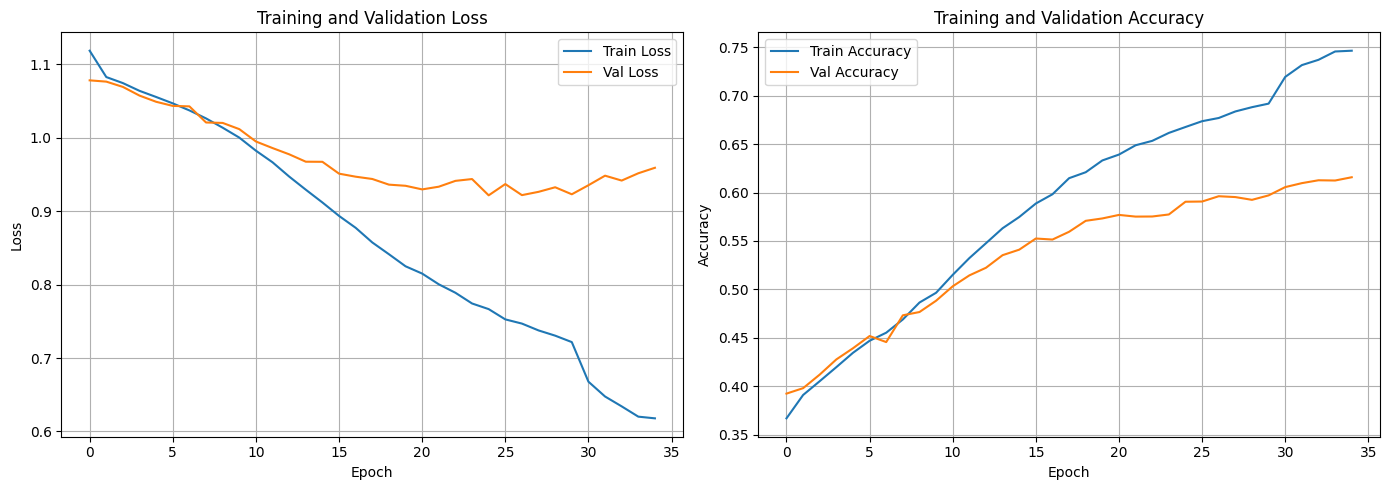

In [16]:
import matplotlib.pyplot as plt

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.60      0.55      0.58      7051
    Hold (0)       0.61      0.62      0.62      7110
     Buy (1)       0.55      0.60      0.57      5379

    accuracy                           0.59     19540
   macro avg       0.59      0.59      0.59     19540
weighted avg       0.59      0.59      0.59     19540



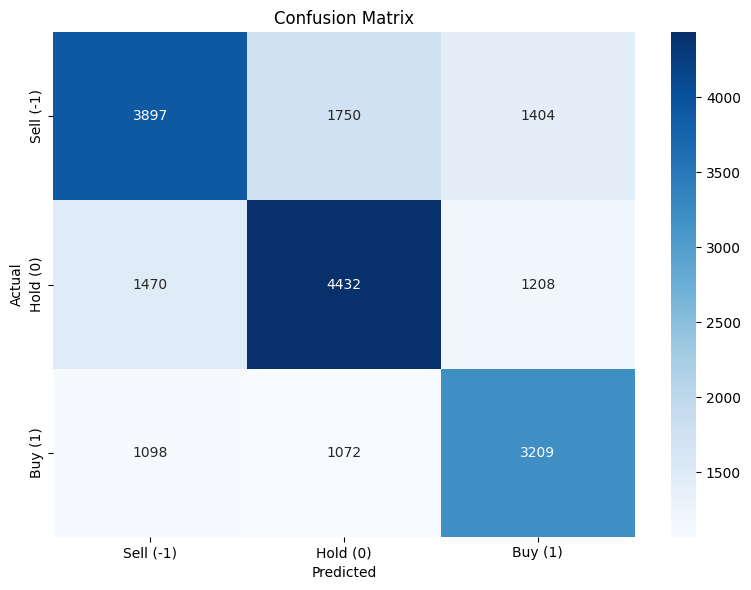


Test Loss: 0.9217
Test Accuracy: 0.5905


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Convert back to original labels for display
label_names = ['Sell (-1)', 'Hold (0)', 'Buy (1)']

# Classification Report
print("Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=label_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Overall metrics
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [19]:
# Save the model
model.save('gru_stock_classifier.h5')
print("Model saved to 'gru_stock_classifier.h5'")

# Save feature list for inference
import json
with open('feature_columns.json', 'w') as f:
    json.dump(features_used, f)
print(f"Feature columns saved ({len(features_used)} features)")

Model saved to 'gru_stock_classifier.h5'
Feature columns saved (38 features)


In [20]:
# Interpret softmax probabilities for trading decisions
def interpret_prediction(proba):
    """
    Interpret model softmax output as Triple Barrier probabilities.

    Args:
        proba: array of shape (3,) - softmax output

    Returns:
        dict with probabilities and recommended action
    """
    p_stop_loss = proba[0]      # P(-1): Hit stop loss
    p_hold = proba[1]           # P(0): Hit time barrier (sideways)
    p_profit = proba[2]         # P(1): Hit profit target

    # Get predicted class
    pred_class = np.argmax(proba) - 1  # Convert back to (-1, 0, 1)
    actions = {-1: 'SELL/SHORT', 0: 'HOLD/NO ACTION', 1: 'BUY/LONG'}

    return {
        'P(Stop Loss)': f"{p_stop_loss:.2%}",
        'P(Hold/Sideways)': f"{p_hold:.2%}",
        'P(Profit Target)': f"{p_profit:.2%}",
        'Recommended Action': actions[pred_class],
        'Confidence': f"{np.max(proba):.2%}"
    }

# Example: Interpret some test predictions
print("Sample Predictions with Probability Interpretation:")
print("=" * 60)
sample_indices = [0, 100, 500, 1000]
for idx in sample_indices:
    if idx < len(X_test):
        proba = y_pred_proba[idx]
        actual = y_true[idx] - 1  # Convert back to (-1, 0, 1)
        interpretation = interpret_prediction(proba)

        print(f"\nSample {idx}:")
        print(f"  Actual Label: {actual} ({['Stop Loss', 'Hold', 'Profit'][actual+1]})")
        for key, val in interpretation.items():
            print(f"  {key}: {val}")

Sample Predictions with Probability Interpretation:

Sample 0:
  Actual Label: -1 (Stop Loss)
  P(Stop Loss): 4.67%
  P(Hold/Sideways): 5.70%
  P(Profit Target): 89.63%
  Recommended Action: BUY/LONG
  Confidence: 89.63%

Sample 100:
  Actual Label: 0 (Hold)
  P(Stop Loss): 5.45%
  P(Hold/Sideways): 14.45%
  P(Profit Target): 80.10%
  Recommended Action: BUY/LONG
  Confidence: 80.10%

Sample 500:
  Actual Label: 0 (Hold)
  P(Stop Loss): 8.87%
  P(Hold/Sideways): 88.16%
  P(Profit Target): 2.96%
  Recommended Action: HOLD/NO ACTION
  Confidence: 88.16%

Sample 1000:
  Actual Label: -1 (Stop Loss)
  P(Stop Loss): 9.39%
  P(Hold/Sideways): 5.77%
  P(Profit Target): 84.84%
  Recommended Action: BUY/LONG
  Confidence: 84.84%
